## Código para calcular errores relativos del primer pico de transmisión y demás

PICO DE TRANSMISIÓN - BARRERA CUADRADA
E_pico_cuadrado = 0.372558 eV
T_pico_cuadrado = 0.999999

PICO DE TRANSMISIÓN - BARRERA SUAVE
E_pico_suave = 0.372721 eV
T_pico_suave = 0.999998

ERRORES RELATIVOS
Error relativo en la energía del pico = 4.385572e-04
Error relativo en la energía del pico = 0.0439 %
Error relativo en la altura del pico = 5.110167e-07
Error relativo en la altura del pico = 0.0001 %


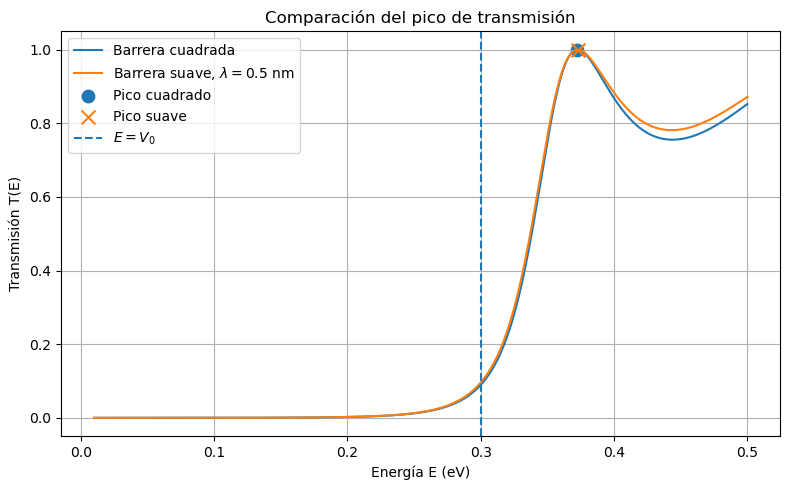

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# PARÁMETROS
# =========================================================

L = 30.0          # longitud total simulada en nm
V0 = 0.3          # altura de la barrera en eV
B = 15.0          # anchura de la barrera en nm
lamb = 0.5        # suavizado en nm

Emin = 0.01
Emax = 0.5
NE = 3000

m_rel = 0.023     # masa efectiva: m* = m_rel m0

hbar2_2m0 = 0.0380998          # eV nm^2
hbar2_2m = hbar2_2m0 / m_rel

# =========================================================
# MALLA ESPACIAL
# =========================================================

N = 3000
x = np.linspace(-L/2, L/2, N)
dx = x[1] - x[0]

# =========================================================
# FUNCIÓN POTENCIAL
# =========================================================
def potencial_suave(x, V0, B, lamb):
    x0 = B/2
    U = (V0/2) * (np.tanh((x + x0)/lamb) - np.tanh((x - x0)/lamb))
    return U

# Potencial ideal cuadrado
def potencial_cuadrado(x, V0, B):
    U = np.zeros_like(x)
    for i in range(len(x)):
        if abs(x[i]) <= B/2:
            U[i] = V0
        else:
            U[i] = 0
    return U

# =========================================================
# POTENCIALES
# =========================================================



U_cuadrado = potencial_cuadrado(x, V0, B)
U_suave = potencial_suave(x, V0, B, lamb)





# =========================================================
# FUNCIÓN PARA CALCULAR LA TRANSMISIÓN
# =========================================================


def matriz_propagacion(E, U, dx, hbar2_2m):
    """
    Matriz que propaga la función de onda en un tramo dx
    donde el potencial vale U.

    Resuelve localmente:
        psi'' + k^2 psi = 0

    con:
        k^2 = (E - U) / (hbar^2 / 2m*)
    """

    k2 = (E - U) / hbar2_2m
    k = np.sqrt(k2 + 0j)   # +0j permite k complejo si E < U

    # Evitamos problemas numéricos si k es muy pequeño
    if abs(k) < 1e-12:
        M = np.array([
            [1.0, dx],
            [0.0, 1.0]
        ], dtype=complex)
    else:
        M = np.array([
            [np.cos(k*dx), np.sin(k*dx)/k],
            [-k*np.sin(k*dx), np.cos(k*dx)]
        ], dtype=complex)

    return M



def transmision(E, U_array, dx, hbar2_2m):
    """
    Calcula la transmisión para una energía E atravesando un potencial U_array.
    
    Se supone que fuera del nanohilo el potencial vale 0:
        U_izquierda = 0
        U_derecha = 0
    """

    # Número de onda en las regiones libres de entrada y salida
    k0 = np.sqrt(E / hbar2_2m + 0j)

    if abs(k0) < 1e-12:
        return 0.0

    # Matriz total
    M_total = np.eye(2, dtype=complex)

    for U in U_array:
        M = matriz_propagacion(E, U, dx, hbar2_2m)
        M_total = M @ M_total

    # En la izquierda:
    # psi_L = exp(ikx) + r exp(-ikx)
    # En la derecha:
    # psi_R = t exp(ikx)
    #
    # Usamos vectores [psi, psi']

    a = np.array([1.0, 1j*k0], dtype=complex)      # onda incidente
    b = np.array([1.0, -1j*k0], dtype=complex)     # onda reflejada
    c = np.array([1.0, 1j*k0], dtype=complex)      # onda transmitida

    # M_total @ (a + r b) = t c
    #
    # r * (M_total @ b) - t * c = - M_total @ a

    A = np.column_stack((M_total @ b, -c))
    rhs = -M_total @ a

    r, t = np.linalg.solve(A, rhs)

    T = abs(t)**2

    return T.real

# =========================================================
# ENERGÍAS
# =========================================================
# Si sabes dónde está el pico, ajusta Emin y Emax para mirar solo esa zona.


E_array = np.linspace(Emin, Emax, NE)

T_cuadrado = np.zeros_like(E_array)
T_suave = np.zeros_like(E_array)

# =========================================================
# CÁLCULO DE TRANSMISIONES
# =========================================================

for i in range(len(E_array)):
    E = E_array[i]

    T_cuadrado[i] = transmision(E, U_cuadrado, dx, hbar2_2m)
    T_suave[i] = transmision(E, U_suave, dx, hbar2_2m)

# Evitamos errores numéricos pequeños
T_cuadrado = np.clip(T_cuadrado, 0, 1)
T_suave = np.clip(T_suave, 0, 1)

# =========================================================
# BUSCAR EL PICO PRINCIPAL
# =========================================================

indice_pico_cuadrado = np.argmax(T_cuadrado)
indice_pico_suave = np.argmax(T_suave)

E_pico_cuadrado = E_array[indice_pico_cuadrado]
E_pico_suave = E_array[indice_pico_suave]

T_pico_cuadrado = T_cuadrado[indice_pico_cuadrado]
T_pico_suave = T_suave[indice_pico_suave]

# =========================================================
# ERRORES RELATIVOS
# =========================================================

error_relativo_E = abs(E_pico_suave - E_pico_cuadrado) / abs(E_pico_cuadrado)
error_relativo_T = abs(T_pico_suave - T_pico_cuadrado) / abs(T_pico_cuadrado)

error_relativo_E_porcentaje = error_relativo_E * 100
error_relativo_T_porcentaje = error_relativo_T * 100

# =========================================================
# RESULTADOS
# =========================================================

print("==============================================")
print("PICO DE TRANSMISIÓN - BARRERA CUADRADA")
print("==============================================")
print(f"E_pico_cuadrado = {E_pico_cuadrado:.6f} eV")
print(f"T_pico_cuadrado = {T_pico_cuadrado:.6f}")

print()
print("==============================================")
print("PICO DE TRANSMISIÓN - BARRERA SUAVE")
print("==============================================")
print(f"E_pico_suave = {E_pico_suave:.6f} eV")
print(f"T_pico_suave = {T_pico_suave:.6f}")

print()
print("==============================================")
print("ERRORES RELATIVOS")
print("==============================================")
print(f"Error relativo en la energía del pico = {error_relativo_E:.6e}")
print(f"Error relativo en la energía del pico = {error_relativo_E_porcentaje:.4f} %")

print(f"Error relativo en la altura del pico = {error_relativo_T:.6e}")
print(f"Error relativo en la altura del pico = {error_relativo_T_porcentaje:.4f} %")

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(E_array, T_cuadrado, label="Barrera cuadrada")
plt.plot(E_array, T_suave, label=fr"Barrera suave, $\lambda={lamb}$ nm")

plt.scatter(E_pico_cuadrado, T_pico_cuadrado, marker="o", s=80, label="Pico cuadrado")
plt.scatter(E_pico_suave, T_pico_suave, marker="x", s=100, label="Pico suave")

plt.axvline(V0, linestyle="--", label=r"$E=V_0$")

plt.xlabel("Energía E (eV)")
plt.ylabel("Transmisión T(E)")
plt.title("Comparación del pico de transmisión")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Ahora para los picos locales

COMPARACIÓN DE PICOS DE TRANSMISIÓN

--------------- PICO 1 ---------------
Barrera cuadrada:
E_pico_cuadrado_1 = 0.372678 eV
T_pico_cuadrado_1 = 0.999999

Barrera suave:
E_pico_suave_1 = 0.372678 eV
T_pico_suave_1 = 0.999995

Errores relativos:
Error relativo en energía = 0.000000e+00
Error relativo en energía = 0.0000 %
Error relativo en altura = 3.488473e-06
Error relativo en altura = 0.0003 %

--------------- PICO 2 ---------------
Barrera cuadrada:
E_pico_cuadrado_2 = 0.590533 eV
T_pico_cuadrado_2 = 1.000000

Barrera suave:
E_pico_suave_2 = 0.591275 eV
T_pico_suave_2 = 1.000000

Errores relativos:
Error relativo en energía = 1.257654e-03
Error relativo en energía = 0.1258 %
Error relativo en altura = 1.661074e-07
Error relativo en altura = 0.0000 %


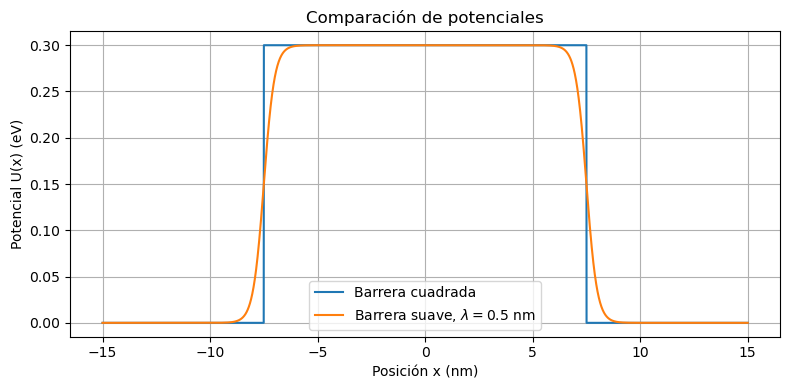

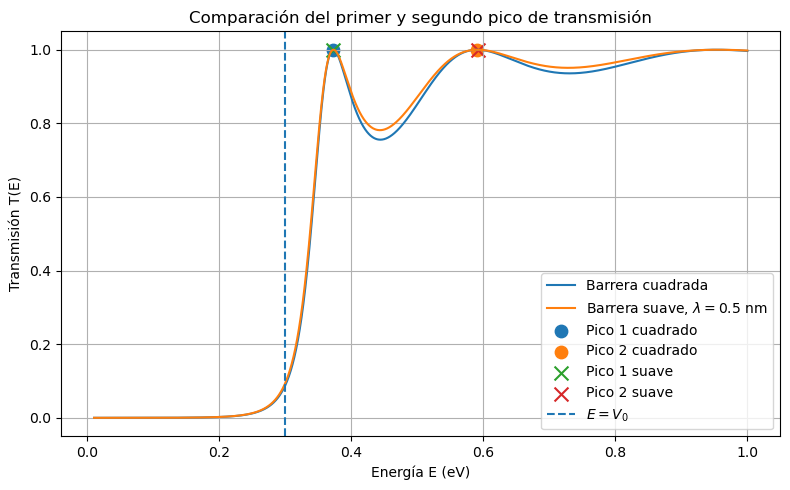

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# PARÁMETROS
# =========================================================

L = 30.0          # longitud total simulada en nm
V0 = 0.3          # altura de la barrera en eV
B = 15.0          # anchura de la barrera en nm
lamb = 0.5        # suavizado en nm

Emin = 0.01
Emax = 1.0
NE = 4000

m_rel = 0.023     # masa efectiva: m* = m_rel m0

hbar2_2m0 = 0.0380998          # eV nm^2
hbar2_2m = hbar2_2m0 / m_rel

# =========================================================
# MALLA ESPACIAL
# =========================================================

N = NE
x = np.linspace(-L/2, L/2, N)
dx = x[1] - x[0]

# =========================================================
# FUNCIÓN POTENCIAL
# =========================================================

def potencial_suave(x, V0, B, lamb):
    x0 = B/2
    U = (V0/2) * (np.tanh((x + x0)/lamb) - np.tanh((x - x0)/lamb))
    return U


def potencial_cuadrado(x, V0, B):
    U = np.zeros_like(x)

    for i in range(len(x)):
        if abs(x[i]) <= B/2:
            U[i] = V0
        else:
            U[i] = 0

    return U

# =========================================================
# POTENCIALES
# =========================================================

U_cuadrado = potencial_cuadrado(x, V0, B)
U_suave = potencial_suave(x, V0, B, lamb)

# =========================================================
# FUNCIÓN PARA CALCULAR LA TRANSMISIÓN
# =========================================================

def matriz_propagacion(E, U, dx, hbar2_2m):
    """
    Matriz que propaga la función de onda en un tramo dx
    donde el potencial vale U.

    Resuelve localmente:
        psi'' + k^2 psi = 0

    con:
        k^2 = (E - U) / (hbar^2 / 2m*)
    """

    k2 = (E - U) / hbar2_2m
    k = np.sqrt(k2 + 0j)

    if abs(k) < 1e-12:
        M = np.array([
            [1.0, dx],
            [0.0, 1.0]
        ], dtype=complex)
    else:
        M = np.array([
            [np.cos(k*dx), np.sin(k*dx)/k],
            [-k*np.sin(k*dx), np.cos(k*dx)]
        ], dtype=complex)

    return M


def transmision(E, U_array, dx, hbar2_2m):
    """
    Calcula la transmisión para una energía E atravesando un potencial U_array.

    Se supone que fuera del potencial:
        U_izquierda = 0
        U_derecha = 0
    """

    k0 = np.sqrt(E / hbar2_2m + 0j)

    if abs(k0) < 1e-12:
        return 0.0

    M_total = np.eye(2, dtype=complex)

    for U in U_array:
        M = matriz_propagacion(E, U, dx, hbar2_2m)
        M_total = M @ M_total

    # En la izquierda:
    # psi_L = exp(ikx) + r exp(-ikx)
    #
    # En la derecha:
    # psi_R = t exp(ikx)

    a = np.array([1.0, 1j*k0], dtype=complex)      # onda incidente
    b = np.array([1.0, -1j*k0], dtype=complex)     # onda reflejada
    c = np.array([1.0, 1j*k0], dtype=complex)      # onda transmitida

    A = np.column_stack((M_total @ b, -c))
    rhs = -M_total @ a

    r, t = np.linalg.solve(A, rhs)

    T = abs(t)**2

    return T.real

# =========================================================
# ENERGÍAS
# =========================================================

E_array = np.linspace(Emin, Emax, NE)

T_cuadrado = np.zeros_like(E_array)
T_suave = np.zeros_like(E_array)

# =========================================================
# CÁLCULO DE TRANSMISIONES
# =========================================================

for i in range(len(E_array)):
    E = E_array[i]

    T_cuadrado[i] = transmision(E, U_cuadrado, dx, hbar2_2m)
    T_suave[i] = transmision(E, U_suave, dx, hbar2_2m)

# Evitamos errores numéricos pequeños
T_cuadrado = np.clip(T_cuadrado, 0, 1)
T_suave = np.clip(T_suave, 0, 1)

# =========================================================
# FUNCIÓN PARA BUSCAR PICOS LOCALES
# =========================================================

def buscar_picos(E_array, T_array, numero_picos=2, altura_minima=0.0):
    """
    Busca máximos locales de T(E).

    Devuelve los primeros 'numero_picos' picos en orden creciente de energía.
    """

    indices_picos = []

    for i in range(1, len(T_array) - 1):

        condicion_maximo = T_array[i] > T_array[i-1] and T_array[i] > T_array[i+1]
        condicion_altura = T_array[i] > altura_minima

        if condicion_maximo and condicion_altura:
            indices_picos.append(i)

    indices_picos = indices_picos[:numero_picos]

    E_picos = E_array[indices_picos]
    T_picos = T_array[indices_picos]

    return indices_picos, E_picos, T_picos

# =========================================================
# BUSCAR PRIMER Y SEGUNDO PICO
# =========================================================

altura_minima = 0.0

indices_picos_cuadrado, E_picos_cuadrado, T_picos_cuadrado = buscar_picos(
    E_array,
    T_cuadrado,
    numero_picos=2,
    altura_minima=altura_minima
)

indices_picos_suave, E_picos_suave, T_picos_suave = buscar_picos(
    E_array,
    T_suave,
    numero_picos=2,
    altura_minima=altura_minima
)

# =========================================================
# COMPROBAR SI SE HAN ENCONTRADO PICOS
# =========================================================

if len(E_picos_cuadrado) < 2:
    print("AVISO: No se han encontrado 2 picos en la barrera cuadrada.")
    print("Prueba a aumentar Emax, aumentar NE o revisar el intervalo de energías.")

if len(E_picos_suave) < 2:
    print("AVISO: No se han encontrado 2 picos en la barrera suave.")
    print("Prueba a aumentar Emax, aumentar NE o revisar el intervalo de energías.")

# =========================================================
# ERRORES RELATIVOS PARA CADA PICO
# =========================================================

numero_picos_encontrados = min(len(E_picos_cuadrado), len(E_picos_suave))

errores_E = []
errores_T = []

for i in range(numero_picos_encontrados):

    error_E = abs(E_picos_suave[i] - E_picos_cuadrado[i]) / abs(E_picos_cuadrado[i])
    error_T = abs(T_picos_suave[i] - T_picos_cuadrado[i]) / abs(T_picos_cuadrado[i])

    errores_E.append(error_E)
    errores_T.append(error_T)

# =========================================================
# RESULTADOS
# =========================================================

print("==============================================")
print("COMPARACIÓN DE PICOS DE TRANSMISIÓN")
print("==============================================")

for i in range(numero_picos_encontrados):

    print()
    print(f"--------------- PICO {i+1} ---------------")

    print("Barrera cuadrada:")
    print(f"E_pico_cuadrado_{i+1} = {E_picos_cuadrado[i]:.6f} eV")
    print(f"T_pico_cuadrado_{i+1} = {T_picos_cuadrado[i]:.6f}")

    print()

    print("Barrera suave:")
    print(f"E_pico_suave_{i+1} = {E_picos_suave[i]:.6f} eV")
    print(f"T_pico_suave_{i+1} = {T_picos_suave[i]:.6f}")

    print()

    print("Errores relativos:")
    print(f"Error relativo en energía = {errores_E[i]:.6e}")
    print(f"Error relativo en energía = {errores_E[i]*100:.4f} %")

    print(f"Error relativo en altura = {errores_T[i]:.6e}")
    print(f"Error relativo en altura = {errores_T[i]*100:.4f} %")

# =========================================================
# PLOT DE POTENCIALES
# =========================================================

plt.figure(figsize=(8, 4))

plt.plot(x, U_cuadrado, label="Barrera cuadrada")
plt.plot(x, U_suave, label=fr"Barrera suave, $\lambda={lamb}$ nm")

plt.xlabel("Posición x (nm)")
plt.ylabel("Potencial U(x) (eV)")
plt.title("Comparación de potenciales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================================
# PLOT DE TRANSMISIÓN
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(E_array, T_cuadrado, label="Barrera cuadrada")
plt.plot(E_array, T_suave, label=fr"Barrera suave, $\lambda={lamb}$ nm")

for i in range(len(E_picos_cuadrado)):
    plt.scatter(
        E_picos_cuadrado[i],
        T_picos_cuadrado[i],
        marker="o",
        s=80,
        label=f"Pico {i+1} cuadrado"
    )

for i in range(len(E_picos_suave)):
    plt.scatter(
        E_picos_suave[i],
        T_picos_suave[i],
        marker="x",
        s=100,
        label=f"Pico {i+1} suave"
    )

plt.axvline(V0, linestyle="--", label=r"$E=V_0$")

plt.xlabel("Energía E (eV)")
plt.ylabel("Transmisión T(E)")
plt.title("Comparación del primer y segundo pico de transmisión")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()